# 📈 Options Volatility Surface Cleaner & Interpolator

Bu notebook, ham opsiyon zinciri verilerini temizleme, eksik noktaları interpole etme ve pürüzsüz bir 3D volatilite yüzeyi oluşturma sürecini kapsar. 

**Proje Akışı:**
1. **Gürültülü Veri Simülasyonu:** Gerçek dünya hatalarını içeren bir veri seti üretimi.
2. **Veri Temizleme:** Quant filtreleri ve aykırı değer (outlier) temizliği.
3. **Matematiksel İnterpolasyon:** Cubic Spline yöntemiyle eksik noktaların doldurulması.
4. **3D Görselleştirme:** Volatility Surface modelleme.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import zscore
from scipy.interpolate import griddata
from matplotlib import cm

# Görselleştirme ayarları
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)
plt.style.use('ggplot')

### Adım 1: Gürültülü Veri Üretimi (Mock Data)
Gerçek piyasalarda opsiyon verileri `NaN` değerler, hatalı girişler ve likidite boşlukları içerir. Burada finansal teoriye uygun (Skew & Smile) ancak gürültülü bir veri seti simüle ediyoruz.

In [12]:
np.random.seed(42)

def generate_noisy_data():
    underlying_price = 450
    strikes = np.arange(380, 521, 5)
    maturities = np.array([15, 30, 60, 90, 180, 270, 360])
    
    data = []
    for t in maturities:
        for s in strikes:
            dist = (s - underlying_price) / underlying_price
            # IV Modeli: Temel + Skew + Smile + Term Structure
            base_iv = 0.15 + (-0.2 * dist) + (0.5 * (dist**2)) + (0.02 * np.sqrt(t/365))
            
            data.append({
                'Strike': s,
                'DaysToMaturity': t,
                'Bid': round(max(0, (1 - 0.05)*5.0), 2),
                'Ask': round((1 + 0.05)*5.0, 2),
                'ImpliedVolatility': base_iv
            })

    df = pd.DataFrame(data)
    
    # Gürültü Ekleme
    df.loc[df.sample(frac=0.1).index, 'ImpliedVolatility'] = np.nan
    df.loc[df.sample(n=5).index, 'ImpliedVolatility'] = 5.0 # Outlier
    df.loc[df.sample(n=5).index, 'ImpliedVolatility'] = 0.0 # Hatalı sıfır
    
    return df

raw_df = generate_noisy_data()
print(f"Ham Veri Özeti:\n{raw_df['ImpliedVolatility'].describe()}")

Ham Veri Özeti:
count    184.000000
mean       0.293394
std        0.789472
min        0.000000
25%        0.149573
50%        0.163276
75%        0.182845
max        5.000000
Name: ImpliedVolatility, dtype: float64


### Adım 2: Veri Temizleme (Quant Cleaning)
Hatalı veri noktalarını filtreleyerek sadece güvenilir noktaları bırakıyoruz.

In [13]:
def clean_data(df):
    # 1. NaN temizliği
    df = df.dropna(subset=['ImpliedVolatility'])
    # 2. Mantıklı IV sınırları
    df = df[(df['ImpliedVolatility'] > 0.01) & (df['ImpliedVolatility'] < 1.5)]
    # 3. Z-Score ile Outlier tespiti
    df = df[abs(zscore(df['ImpliedVolatility'])) < 3]
    return df

cleaned_df = clean_data(raw_df)
print(f"Temizlenmiş Satır Sayısı: {len(cleaned_df)} / {len(raw_df)}")

Temizlenmiş Satır Sayısı: 174 / 203


### Adım 3: Matematiksel İnterpolasyon
Temizlenmiş verideki boşlukları doldurmak için 2D `Cubic` interpolasyon kullanarak pürüzsüz bir yüzey matrisi (grid) oluşturuyoruz.

In [14]:
points = cleaned_df[['DaysToMaturity', 'Strike']].values
values = cleaned_df['ImpliedVolatility'].values

# Hedef Grid
ti = np.linspace(cleaned_df['DaysToMaturity'].min(), cleaned_df['DaysToMaturity'].max(), 50)
si = np.linspace(cleaned_df['Strike'].min(), cleaned_df['Strike'].max(), 50)
T, S = np.meshgrid(ti, si)

# Interpolasyon
IV_Surface = griddata(points, values, (T, S), method='cubic')

# Kenar düzeltme (Linear fill)
nan_mask = np.isnan(IV_Surface)
IV_Surface[nan_mask] = griddata(points, values, (T[nan_mask], S[nan_mask]), method='linear')

print("Yüzey matrisi başarıyla oluşturuldu.")

Yüzey matrisi başarıyla oluşturuldu.


### Adım 4: 3D Görselleştirme
Son olarak, elde ettiğimiz temiz ve interpole edilmiş veriyi profesyonel bir 3D grafiğe dönüştürüyoruz.

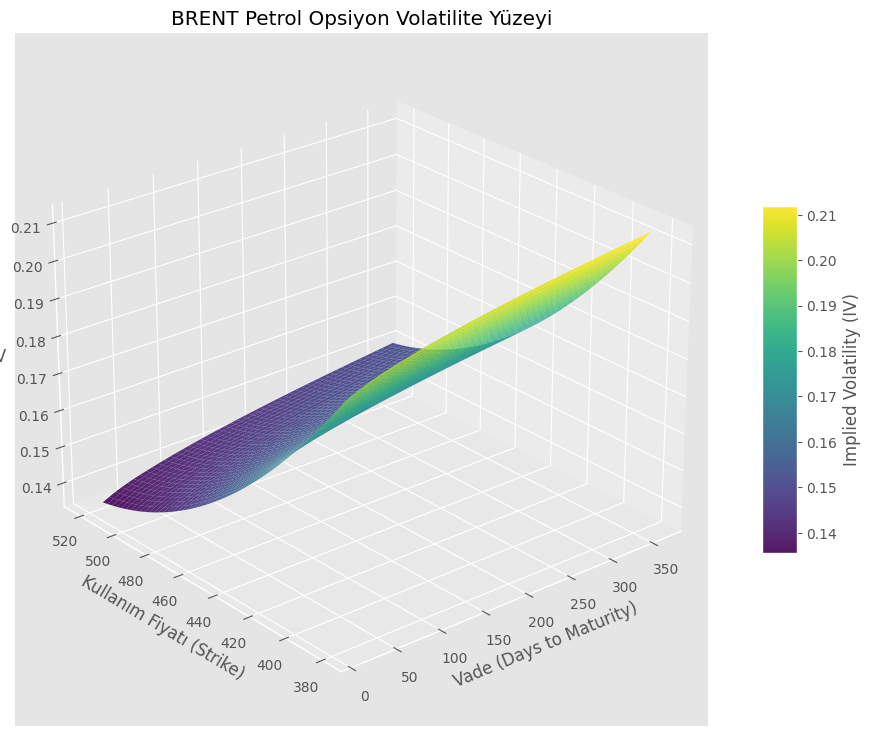

In [15]:
fig = plt.figure(figsize=(14, 9))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(T, S, IV_Surface, cmap=cm.viridis,
                       linewidth=0.1, antialiased=True, alpha=0.9)

fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label='Implied Volatility (IV)')

ax.set_xlabel('Vade (Days to Maturity)')
ax.set_ylabel('Kullanım Fiyatı (Strike)')
ax.set_zlabel('IV')
ax.set_title('BRENT Petrol Opsiyon Volatilite Yüzeyi')

ax.view_init(elev=25, azim=-130)
plt.show()